In [ ]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv


In [ ]:
from google.colab import files
uploaded = files.upload()

import copy
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

train_raw = pd.read_csv('train.csv')
test_raw = pd.read_csv('test.csv')
print('Training shape:', train_raw.shape)
print('Kaggle test shape:', test_raw.shape)

KeyboardInterrupt: 

In [ ]:
# Shared feature engineering, preprocessing, and validation split
def engineer_features(data):
    result = data[['PassengerId', 'Pclass', 'Name', 'Sex', 'Age',
                   'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
    result['FamilySize'] = result['SibSp'] + result['Parch'] + 1
    result['IsAlone'] = (result['FamilySize'] == 1).astype(int)
    result['FarePerPerson'] = result['Fare'] / result['FamilySize']
    result['Title'] = result['Name'].str.extract(r',\s*([^.]*)\.', expand=False)
    common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
    result['Title'] = result['Title'].where(result['Title'].isin(common_titles), 'Rare')
    return result.drop(columns=['Name']).set_index('PassengerId')

X_all = engineer_features(train_raw)
X_kaggle = engineer_features(test_raw)
y_all = train_raw.set_index('PassengerId')['Survived']

numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
                    'FamilySize', 'IsAlone', 'FarePerPerson']
categorical_features = ['Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.33, random_state=10, stratify=y_all
)

assert len(X_valid) == 295
assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)
print('Shared features:', X_all.columns.tolist())
print('Training rows:', len(X_train), '| Validation rows:', len(X_valid))

Shared features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Title']
Training rows: 596 | Validation rows: 295


In [ ]:
import pandas as pd

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier
)
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

models = {
    "Gradient Boosting": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", GradientBoostingClassifier(
            learning_rate=0.1,
            max_depth=2,
            n_estimators=50,
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", SVC(
            C=5,
            class_weight=None,
            gamma=0.01,
            kernel="rbf"
        ))
    ]),

    "Decision Tree": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", DecisionTreeClassifier(
            criterion="entropy",
            max_depth=8,
            min_samples_leaf=5,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            max_features=0.75,
            min_samples_leaf=1,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "AdaBoost": Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", AdaBoostClassifier(
            learning_rate=1.0,
            n_estimators=200,
            random_state=42
        ))
    ])
}


# train and evaluate
result_rows = []

for model_name, model in models.items():
    model.fit(X_train, y_train)

    training_predictions = model.predict(X_train)
    validation_predictions = model.predict(X_valid)

    training_accuracy = accuracy_score(
        y_train,
        training_predictions
    )

    validation_accuracy = accuracy_score(
        y_valid,
        validation_predictions
    )

    tn, fp, fn, tp = confusion_matrix(
        y_valid,
        validation_predictions,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    result_rows.append({
        "Model": model_name,
        "TrainingAccuracy": training_accuracy,
        "Accuracy": validation_accuracy,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "FPR": fpr,
        "FNR": fnr
    })


results = pd.DataFrame(result_rows)


# check dominance
def is_dominated(row, table):
    better_or_equal = (
        (table["FPR"] <= row["FPR"]) &
        (table["FNR"] <= row["FNR"])
    )

    strictly_better = (
        (table["FPR"] < row["FPR"]) |
        (table["FNR"] < row["FNR"])
    )

    return (better_or_equal & strictly_better).any()


results["Dominated"] = results.apply(
    lambda row: is_dominated(row, results),
    axis=1
)

results["ParetoOptimal"] = ~results["Dominated"]

results = results.sort_values(
    ["FPR", "FNR"]
).reset_index(drop=True)

frontier = results[
    results["ParetoOptimal"]
].copy()


display(
    results[
        [
            "Model",
            "Accuracy",
            "FPR",
            "FNR",
            "Dominated",
            "ParetoOptimal"
        ]
    ]
)

,Model,Accuracy,FPR,FNR,Dominated,ParetoOptimal
0,Gradient Boosting,0.840678,0.093407,0.265487,False,True
1,SVM,0.840678,0.104396,0.247788,False,True
2,Decision Tree,0.854237,0.109890,0.203540,False,True
3,Random Forest,0.854237,0.109890,0.203540,False,True
4,AdaBoost,0.830508,0.181319,0.150442,False,True


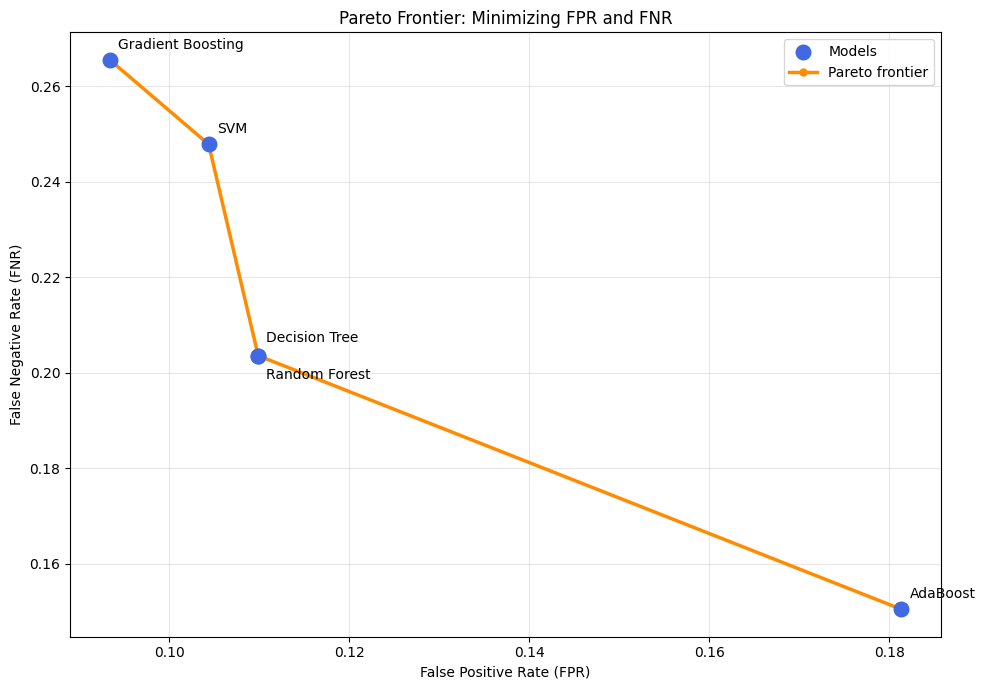

In [ ]:
import matplotlib.pyplot as plt

frontier_line = (
    frontier[["FPR", "FNR"]]
    .drop_duplicates()
    .sort_values("FPR")
)


plt.figure(figsize=(10, 7))

plt.scatter(
    results["FPR"],
    results["FNR"],
    color="royalblue",
    s=110,
    zorder=3,
    label="Models"
)

plt.plot(
    frontier_line["FPR"],
    frontier_line["FNR"],
    color="darkorange",
    linewidth=2.5,
    marker="o",
    markersize=5,
    label="Pareto frontier",
    zorder=2
)

label_offsets = {
    "Gradient Boosting": (6, 8),
    "SVM": (6, 8),
    "Decision Tree": (6, 10),
    "Random Forest": (6, -17),
    "AdaBoost": (6, 8)
}

for _, row in results.iterrows():
    x_offset, y_offset = label_offsets[row["Model"]]

    plt.annotate(
        row["Model"],
        (row["FPR"], row["FNR"]),
        xytext=(x_offset, y_offset),
        textcoords="offset points",
        fontsize=10
    )


plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("False Negative Rate (FNR)")
plt.title("Pareto Frontier: Minimizing FPR and FNR")

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import zipfile
from sklearn.base import clone
from google.colab import files


prediction_files = []

for model_name, validation_model in models.items():

    final_model = clone(validation_model)

    final_model.fit(X_all, y_all)

    test_predictions = final_model.predict(X_kaggle).astype(int)

    submission = pd.DataFrame({
        "PassengerId": test_raw["PassengerId"],
        "Survived": test_predictions
    })

    filename = (
        model_name.lower()
        .replace(" ", "_")
        + "_predictions.csv"
    )

    submission.to_csv(filename, index=False)
    prediction_files.append(filename)

    print(f"Created {filename}: {len(submission)} predictions")


zip_filename = "titanic_all_model_predictions.zip"

with zipfile.ZipFile(zip_filename, "w") as zip_file:
    for filename in prediction_files:
        zip_file.write(filename)


print("\nCSV files created:")
for filename in prediction_files:
    print("-", filename)

print(f"\nDownloading {zip_filename}...")

files.download(zip_filename)